# Forecast `deals_next_quarter`: NB with Exposure

В этом ноутбуке:
- данные читаются только из `parquet`;
- целевая: `deals_next_q` (кол-во сделок в следующий квартал);
- exposure: `remaining_lots_start_q` (остаток лотов на начало текущего квартала);
- базовая модель: **Negative Binomial with offset**;
- сравнение с benchmark-моделями и метрики по классам жилья.


In [172]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from scipy.stats import nbinom, poisson

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 250
pd.options.display.width = 260
plt.style.use("seaborn-v0_8-whitegrid")


def show_table(df: pd.DataFrame, caption: str | None = None, round_map: dict | None = None):
    if caption:
        print(f"\n{caption}")
    out = df.copy()
    if round_map:
        for col, digits in round_map.items():
            if col in out.columns:
                out[col] = out[col].round(digits)
    display(out)


In [173]:
REGION_KEY = "Москва"

DATA_DIR = Path("..") / "data"
DEALS_DIR = DATA_DIR / "deals_parquet"
PROJECTS_DIR = DATA_DIR / "projects_parquet"


def find_region_parquet_files(folder: Path, region_key: str | None) -> list[Path]:
    files = sorted(folder.glob("*.parquet"))
    if region_key:
        key = region_key.lower()
        files = [p for p in files if key in p.name.lower()]
    return files


DEALS_PARQUET_FILES = find_region_parquet_files(DEALS_DIR, REGION_KEY)
PROJECTS_PARQUET_FILES = find_region_parquet_files(PROJECTS_DIR, REGION_KEY)

if not DEALS_PARQUET_FILES:
    raise FileNotFoundError(f"No deals parquet files for region: {REGION_KEY}")
if not PROJECTS_PARQUET_FILES:
    raise FileNotFoundError(f"No projects parquet files for region: {REGION_KEY}")

print("Region:", REGION_KEY)
print("Deals files:", len(DEALS_PARQUET_FILES))
for p in DEALS_PARQUET_FILES:
    print(" -", p)
print("Projects files:", len(PROJECTS_PARQUET_FILES))
for p in PROJECTS_PARQUET_FILES:
    print(" -", p)


Region: Москва
Deals files: 1
 - ..\data\deals_parquet\bnMAP_pro_Сделки_Москва_09-02-2026_12-17_part1.parquet
Projects files: 2
 - ..\data\projects_parquet\bnMAP_pro_ПД_Москва_09-02-2026_12-45_part1.parquet
 - ..\data\projects_parquet\bnMAP_pro_ПД_Москва_09-02-2026_12-45_part2.parquet


## 1) Построение квартальной витрины `project-quarter`

Ключевая логика exposure:
- `total_lots`: число уникальных лотов в проекте (из ПД);
- `cum_sales_prev_q`: накопленные продажи до начала квартала;
- `remaining_lots_start_q = total_lots - cum_sales_prev_q` (с ограничением снизу `1`);
- в модели NB этот exposure идет в `offset` как `log(exposure)`.


In [174]:
def to_datetime_series(series: pd.Series) -> pd.Series:
    x = series.replace({"nan": pd.NA, "None": pd.NA, "": pd.NA})
    parsed = pd.to_datetime(x, errors="coerce", dayfirst=True, utc=True)
    if hasattr(parsed, "dt"):
        parsed = parsed.dt.tz_localize(None)
    num = pd.to_numeric(x, errors="coerce")
    excel_dt = pd.to_datetime(num, unit="D", origin="1899-12-30", errors="coerce")
    return parsed.fillna(excel_dt)


def to_float_series(series: pd.Series) -> pd.Series:
    x = (
        series.astype(str)
        .str.replace("\xa0", "", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace(",", ".", regex=False)
        .replace({"nan": np.nan, "None": np.nan, "": np.nan})
    )
    return pd.to_numeric(x, errors="coerce")


def normalize_class(x: object) -> str:
    if x is None or pd.isna(x):
        return "Неизвестно"
    s = str(x).strip().lower()
    if "комфорт" in s:
        return "Комфорт"
    if "премиум" in s:
        return "Премиум"
    if "бизнес" in s:
        return "Бизнес"
    if "эконом" in s:
        return "Эконом"
    if not s:
        return "Неизвестно"
    return str(x).strip().title()


def normalize_room_type(x: object) -> str:
    if x is None or pd.isna(x):
        return "other"
    s = str(x).strip().lower()
    if s in {"ст", "studio", "0", "студия"}:
        return "studio"
    if s in {"1", "1к", "1-комн", "1 комн"}:
        return "1r"
    if s in {"2", "2к", "3", "3к", "4", "4к", "5", "5к"}:
        return "2plus"
    return "other"


def mode_or_unknown(s: pd.Series) -> str:
    vals = s.dropna().astype(str).str.strip()
    if vals.empty:
        return "Неизвестно"
    m = vals.mode()
    return m.iloc[0] if not m.empty else vals.iloc[0]


In [175]:
import pyarrow.parquet as pq

DEALS_COLS = [
    "ID проекта",
    "Дата договора",
    "Цена за кв. метр",
    "Площадь согласно ЕГРН",
    "Универсальная комнатность",
    "Класс",
]
PROJECTS_COLS = [
    "ID проекта",
    "ID лота",
    "Класс",
    "Район",
    "Конструктив",
    "Старт продаж",
    "Плановая дата РВЭ",
]


def read_parquet_with_normalized_columns(path: Path, required_cols: list[str]) -> pd.DataFrame:
    schema_cols = pq.ParquetFile(path).schema.names
    by_norm = {str(c).strip(): c for c in schema_cols}
    actual_cols = [by_norm[c] for c in required_cols if c in by_norm]

    part = pd.read_parquet(path, columns=actual_cols if actual_cols else None)
    part = part.rename(columns=lambda c: str(c).strip())

    for c in required_cols:
        if c not in part.columns:
            part[c] = pd.NA
    return part[required_cols]


def read_many_parquet(paths: list[Path], required_cols: list[str], label: str) -> pd.DataFrame:
    frames = []
    for p in paths:
        part = read_parquet_with_normalized_columns(p, required_cols)
        print(f"{label}: {p.name} -> {part.shape}")
        frames.append(part)
    out = pd.concat(frames, axis=0, ignore_index=True)
    print(f"{label} total shape: {out.shape}")
    return out


deals = read_many_parquet(DEALS_PARQUET_FILES, DEALS_COLS, "deals").copy()
projects = read_many_parquet(PROJECTS_PARQUET_FILES, PROJECTS_COLS, "projects").copy()

projects = projects.drop_duplicates(subset=["ID проекта", "ID лота"]).reset_index(drop=True)

deals["project_id"] = deals["ID проекта"].astype("string").str.strip()
projects["project_id"] = projects["ID проекта"].astype("string").str.strip()

deals = deals[deals["project_id"].notna() & (deals["project_id"] != "")]
projects = projects[projects["project_id"].notna() & (projects["project_id"] != "")]

deals["deal_date"] = to_datetime_series(deals["Дата договора"])
deals = deals[deals["deal_date"].notna()].copy()
deals["quarter"] = deals["deal_date"].dt.to_period("Q")

deals["price_sqm"] = to_float_series(deals["Цена за кв. метр"])
deals["area_sqm"] = to_float_series(deals["Площадь согласно ЕГРН"])
deals["room_type"] = deals["Универсальная комнатность"].map(normalize_room_type)
deals["class_group"] = deals["Класс"].map(normalize_class)

deals.head(3)


deals: bnMAP_pro_Сделки_Москва_09-02-2026_12-17_part1.parquet -> (858157, 6)
deals total shape: (858157, 6)
projects: bnMAP_pro_ПД_Москва_09-02-2026_12-45_part1.parquet -> (900000, 7)
projects: bnMAP_pro_ПД_Москва_09-02-2026_12-45_part2.parquet -> (358130, 7)
projects total shape: (1258130, 7)


,ID проекта,Дата договора,Цена за кв. метр,Площадь согласно ЕГРН,Универсальная комнатность,Класс,project_id,deal_date,quarter,price_sqm,area_sqm,room_type,class_group
0,d1e2e1ebb5fa770f2b1806629baf4e36,2002-11-12,468204,34.40,1,Комфорт,d1e2e1ebb5fa770f2b1806629baf4e36,2002-11-12,2002Q4,468204.0,34.4,1r,Комфорт
1,c4a6b151c46627e290df68992b9075df,2009-05-25,<NA>,186.00,4,Бизнес,c4a6b151c46627e290df68992b9075df,2009-05-25,2009Q2,NaN,186.0,2plus,Бизнес
2,c4a6b151c46627e290df68992b9075df,2009-05-25,<NA>,137.60,3,Бизнес,c4a6b151c46627e290df68992b9075df,2009-05-25,2009Q2,NaN,137.6,2plus,Бизнес


In [176]:
# Quarterly aggregates from deals (features at quarter q)
q_sales = (
    deals.groupby(["project_id", "quarter"], as_index=False)
    .agg(
        deals_q=("project_id", "size"),
        avg_price_sqm_q=("price_sqm", "mean"),
        median_price_sqm_q=("price_sqm", "median"),
        avg_area_q=("area_sqm", "mean"),
        studio_sales_q=("room_type", lambda s: (s == "studio").sum()),
        room1_sales_q=("room_type", lambda s: (s == "1r").sum()),
        room2plus_sales_q=("room_type", lambda s: (s == "2plus").sum()),
    )
)
q_sales["share_studio_q"] = q_sales["studio_sales_q"] / q_sales["deals_q"].clip(lower=1)
q_sales["share_1r_q"] = q_sales["room1_sales_q"] / q_sales["deals_q"].clip(lower=1)
q_sales["share_2plus_q"] = q_sales["room2plus_sales_q"] / q_sales["deals_q"].clip(lower=1)

# Project-level metadata from projects parquet
# Prepare project dates before aggregation (mixed object/date values are common in source exports)
projects["start_sales_dt"] = to_datetime_series(projects["Старт продаж"])
projects["planned_rve_dt"] = to_datetime_series(projects["Плановая дата РВЭ"])

proj_total_lots = (
    projects.groupby("project_id", as_index=False)["ID лота"]
    .nunique()
    .rename(columns={"ID лота": "total_lots"})
)
proj_meta = (
    projects.groupby("project_id", as_index=False)
    .agg(
        class_group=("Класс", mode_or_unknown),
        district=("Район", mode_or_unknown),
        building_type=("Конструктив", mode_or_unknown),
        start_sales=("start_sales_dt", "min"),
        planned_rve=("planned_rve_dt", "min"),
    )
)
proj_meta["class_group"] = proj_meta["class_group"].map(normalize_class)
proj_meta["district"] = proj_meta["district"].fillna("Неизвестно").astype(str)
proj_meta["building_type"] = proj_meta["building_type"].fillna("Неизвестно").astype(str)
proj_meta["start_sales"] = to_datetime_series(proj_meta["start_sales"])
proj_meta["planned_rve"] = to_datetime_series(proj_meta["planned_rve"])

# Build complete panel between first and last observed quarter for each project
bounds = q_sales.groupby("project_id", as_index=False).agg(q_min=("quarter", "min"), q_max=("quarter", "max"))
rows = []
for r in bounds.itertuples(index=False):
    for q in pd.period_range(r.q_min, r.q_max, freq="Q"):
        rows.append((r.project_id, q))
panel = pd.DataFrame(rows, columns=["project_id", "quarter"])

panel = panel.merge(q_sales, on=["project_id", "quarter"], how="left")
panel["deals_q"] = panel["deals_q"].fillna(0).astype(int)
for c in ["avg_price_sqm_q", "median_price_sqm_q", "avg_area_q"]:
    panel[c] = panel[c].astype(float)
for c in ["share_studio_q", "share_1r_q", "share_2plus_q", "studio_sales_q", "room1_sales_q", "room2plus_sales_q"]:
    panel[c] = panel[c].fillna(0)

panel = panel.merge(proj_total_lots, on="project_id", how="left")
panel = panel.merge(proj_meta, on="project_id", how="left")

# Fill missing static fields
panel["class_group"] = panel["class_group"].fillna("Неизвестно")
panel["district"] = panel["district"].fillna("Неизвестно")
panel["building_type"] = panel["building_type"].fillna("Неизвестно")

# Fill numerical features project-wise where possible
for c in ["avg_price_sqm_q", "median_price_sqm_q", "avg_area_q"]:
    panel[c] = panel.groupby("project_id")[c].ffill()
    panel[c] = panel.groupby("project_id")[c].bfill()
    panel[c] = panel[c].fillna(panel[c].median())

panel = panel.sort_values(["project_id", "quarter"]).reset_index(drop=True)
panel["quarter_num"] = panel["quarter"].dt.quarter.astype(int)

# Lag features and rolling
panel["deals_q_l1"] = panel.groupby("project_id")["deals_q"].shift(1).fillna(0)
panel["deals_q_l2"] = panel.groupby("project_id")["deals_q"].shift(2).fillna(0)
panel["deals_last_12m"] = (
    panel.groupby("project_id")["deals_q"]
    .rolling(4, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
    .shift(1)
    .fillna(0)
)
panel["rolling_mean_2q"] = (
    panel.groupby("project_id")["deals_q"]
    .rolling(2, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
    .shift(1)
    .fillna(0)
)
panel["rolling_mean_4q"] = (
    panel.groupby("project_id")["deals_q"]
    .rolling(4, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
    .shift(1)
    .fillna(0)
)

# Price growth qoq (feature at q)
panel["price_growth_qoq"] = panel.groupby("project_id")["avg_price_sqm_q"].pct_change().replace([np.inf, -np.inf], np.nan)
panel["price_growth_qoq"] = panel["price_growth_qoq"].fillna(0.0).clip(-1.0, 3.0)

# Exposure = remaining lots at start of quarter
panel["total_lots"] = pd.to_numeric(panel["total_lots"], errors="coerce").fillna(0).astype(int)
lots_fallback = int(panel.loc[panel["total_lots"] > 0, "total_lots"].median())
if lots_fallback <= 0:
    lots_fallback = 1
panel["total_lots"] = panel["total_lots"].replace(0, lots_fallback)

panel["cum_sales_prev_q"] = panel.groupby("project_id")["deals_q"].cumsum().shift(1).fillna(0)
panel["remaining_lots_start_q"] = (panel["total_lots"] - panel["cum_sales_prev_q"]).clip(lower=1)
panel["remaining_inventory_share"] = (panel["remaining_lots_start_q"] / panel["total_lots"]).clip(0, 1)
panel["share_sold_already"] = 1 - panel["remaining_inventory_share"]

# Project age / time to delivery
panel["start_q"] = to_datetime_series(panel["start_sales"]).dt.to_period("Q")
panel["rve_q"] = to_datetime_series(panel["planned_rve"]).dt.to_period("Q")
panel["q_ord"] = panel["quarter"].map(lambda p: p.ordinal)
panel["start_q_ord"] = panel["start_q"].map(lambda p: p.ordinal if pd.notna(p) else np.nan)
panel["rve_q_ord"] = panel["rve_q"].map(lambda p: p.ordinal if pd.notna(p) else np.nan)
panel["project_age_q"] = (panel["q_ord"] - panel["start_q_ord"] + 1).clip(lower=0)
panel["project_age_q"] = panel["project_age_q"].fillna(panel["project_age_q"].median())
panel["quarters_to_delivery"] = panel["rve_q_ord"] - panel["q_ord"]
panel["quarters_to_delivery"] = panel["quarters_to_delivery"].fillna(panel["quarters_to_delivery"].median())

# Target: next quarter deals
panel["deals_next_q"] = panel.groupby("project_id")["deals_q"].shift(-1)
model_df = panel[panel["deals_next_q"].notna()].copy()
model_df["deals_next_q"] = model_df["deals_next_q"].astype(int)

model_df.head(3)


,project_id,quarter,deals_q,avg_price_sqm_q,median_price_sqm_q,avg_area_q,studio_sales_q,room1_sales_q,room2plus_sales_q,share_studio_q,share_1r_q,share_2plus_q,total_lots,class_group,district,building_type,start_sales,planned_rve,quarter_num,deals_q_l1,deals_q_l2,deals_last_12m,rolling_mean_2q,rolling_mean_4q,price_growth_qoq,cum_sales_prev_q,remaining_lots_start_q,remaining_inventory_share,share_sold_already,start_q,rve_q,q_ord,start_q_ord,rve_q_ord,project_age_q,quarters_to_delivery,deals_next_q
0,000fe19da9069595b5a70361bc048cd5,2017Q2,9,296208.888889,292650.0,66.166667,1.0,0.0,8.0,0.111111,0.0,0.888889,305,Бизнес,Гагаринский,Монолит-кирпич,2017-01-04,NaT,2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,305.0,1.000000,0.000000,2017Q1,NaT,189,188.0,NaN,2.0,6.0,28
1,000fe19da9069595b5a70361bc048cd5,2017Q3,28,297807.900000,297218.5,58.714286,0.0,10.0,18.0,0.0,0.357143,0.642857,305,Бизнес,Гагаринский,Монолит-кирпич,2017-01-04,NaT,3,9.0,0.0,9.0,9.0,9.0,0.005398,9.0,296.0,0.970492,0.029508,2017Q1,NaT,190,188.0,NaN,3.0,6.0,41
2,000fe19da9069595b5a70361bc048cd5,2017Q4,41,274942.246341,272919.1,59.487805,3.0,9.0,29.0,0.073171,0.219512,0.707317,305,Бизнес,Гагаринский,Монолит-кирпич,2017-01-04,NaT,4,28.0,9.0,37.0,18.5,18.5,-0.076780,37.0,268.0,0.878689,0.121311,2017Q1,NaT,191,188.0,NaN,4.0,6.0,19


In [177]:
summary = pd.DataFrame(
    {
        "rows_total": [len(model_df)],
        "projects": [model_df["project_id"].nunique()],
        "min_quarter": [str(model_df["quarter"].min())],
        "max_quarter": [str(model_df["quarter"].max())],
        "mean_target_deals_next_q": [model_df["deals_next_q"].mean()],
        "mean_exposure": [model_df["remaining_lots_start_q"].mean()],
    }
)
show_table(summary, "Параметры обучающей витрины", {"mean_target_deals_next_q": 2, "mean_exposure": 2})

class_summary = (
    model_df.groupby("class_group", as_index=False)
    .agg(
        rows=("deals_next_q", "size"),
        projects=("project_id", "nunique"),
        mean_target=("deals_next_q", "mean"),
        mean_exposure=("remaining_lots_start_q", "mean"),
    )
    .sort_values("rows", ascending=False)
)
show_table(class_summary, "Срез по классам", {"mean_target": 2, "mean_exposure": 2})



Параметры обучающей витрины


,rows_total,projects,min_quarter,max_quarter,mean_target_deals_next_q,mean_exposure
0,9877,689,2002Q4,2025Q4,84.05,1790.23



Срез по классам


,class_group,rows,projects,mean_target,mean_exposure
1,Комфорт,3899,256,115.92,2088.09
0,Бизнес,3869,274,82.23,2036.31
5,Элитный,867,73,11.20,357.95
3,Премиум,807,59,26.86,888.65
2,Неизвестно,359,22,44.73,1250.38
4,Эконом,76,5,165.34,2444.36


## 2) Модели

Модели в сравнении:
1. `NB_offset` — Negative Binomial с offset `log(exposure)` (основная).
2. `Poisson_offset` — Poisson с offset `log(exposure)` (benchmark).
3. `NB_no_offset` — Negative Binomial без offset, но с `log(exposure)` как обычной фичей.
4. `OLS_baseline` — грубый baseline (клип на 0).

Валидация: temporal holdout по кварталам (последние кварталы в test).


In [178]:
def poisson_deviance(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float).clip(1e-9, None)
    term = np.where(y_true > 0, y_true * np.log(y_true / y_pred), 0.0)
    return float(2 * np.sum(term - (y_true - y_pred)))


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def distribution_chi2(y_true: np.ndarray, mu: np.ndarray, dist: str, alpha: float | None = None):
    y = np.asarray(y_true, dtype=int)
    mu = np.asarray(mu, dtype=float).clip(1e-9, None)
    k_max = int(max(20, min(int(y.max()), int(np.quantile(y, 0.99)) + 5)))

    obs = np.bincount(np.minimum(y, k_max), minlength=k_max + 1).astype(float)
    exp_main = []
    if dist == "poisson":
        for k in range(k_max):
            exp_main.append(float(np.sum(poisson.pmf(k, mu))))
    elif dist == "nb":
        a = float(max(alpha if alpha is not None else 0.3, 1e-9))
        r = 1.0 / a
        p = r / (r + mu)
        for k in range(k_max):
            exp_main.append(float(np.sum(nbinom.pmf(k, r, p))))
    else:
        return np.nan, 0, k_max

    exp_main = np.array(exp_main, dtype=float)
    tail = float(len(y) - np.sum(exp_main))
    exp = np.concatenate([exp_main, [max(tail, 1e-9)]])
    mask = exp >= 1.0
    chi2 = float(np.sum(((obs[mask] - exp[mask]) ** 2) / exp[mask])) if mask.any() else np.nan
    return chi2, int(mask.sum()), k_max


def prepare_design(train_df: pd.DataFrame, test_df: pd.DataFrame, include_log_exposure_as_feature: bool = False):
    numeric_cols = [
        "deals_q",
        "deals_q_l1",
        "deals_q_l2",
        "deals_last_12m",
        "rolling_mean_2q",
        "rolling_mean_4q",
        "avg_price_sqm_q",
        "median_price_sqm_q",
        "price_growth_qoq",
        "avg_area_q",
        "share_studio_q",
        "share_1r_q",
        "share_2plus_q",
        "project_age_q",
        "quarters_to_delivery",
        "remaining_inventory_share",
        "share_sold_already",
    ]
    cat_cols = ["class_group", "district", "building_type", "quarter_num"]

    tr = train_df.copy()
    te = test_df.copy()

    if include_log_exposure_as_feature:
        tr["log_exposure_feat"] = np.log(np.clip(tr["remaining_lots_start_q"], 1.0, None))
        te["log_exposure_feat"] = np.log(np.clip(te["remaining_lots_start_q"], 1.0, None))
        numeric_cols = numeric_cols + ["log_exposure_feat"]

    for c in numeric_cols:
        tr[c] = pd.to_numeric(tr[c], errors="coerce")
        te[c] = pd.to_numeric(te[c], errors="coerce")

    tr[numeric_cols] = tr[numeric_cols].replace([np.inf, -np.inf], np.nan)
    te[numeric_cols] = te[numeric_cols].replace([np.inf, -np.inf], np.nan)

    med = tr[numeric_cols].median()
    tr[numeric_cols] = tr[numeric_cols].fillna(med)
    te[numeric_cols] = te[numeric_cols].fillna(med)

    # Winsorize + scale numerical columns for stable GLM optimization.
    for c in numeric_cols:
        lo = float(tr[c].quantile(0.005))
        hi = float(tr[c].quantile(0.995))
        if not np.isfinite(lo):
            lo = -1e9
        if not np.isfinite(hi):
            hi = 1e9
        if lo > hi:
            lo, hi = hi, lo

        tr[c] = tr[c].clip(lo, hi)
        te[c] = te[c].clip(lo, hi)

        mean = float(tr[c].mean())
        std = float(tr[c].std())
        if not np.isfinite(std) or std < 1e-8:
            std = 1.0
        tr[c] = (tr[c] - mean) / std
        te[c] = (te[c] - mean) / std

    # Keep top categories, bucket the rest into OTHER.
    for c in cat_cols:
        tr[c] = tr[c].astype("string").fillna("UNK")
        te[c] = te[c].astype("string").fillna("UNK")
        top_vals = tr[c].value_counts().head(25).index
        tr[c] = tr[c].where(tr[c].isin(top_vals), "OTHER")
        te[c] = te[c].where(te[c].isin(top_vals), "OTHER")

    x_train = pd.get_dummies(tr[numeric_cols + cat_cols], columns=cat_cols, drop_first=True, dtype=float)
    x_test = pd.get_dummies(te[numeric_cols + cat_cols], columns=cat_cols, drop_first=True, dtype=float)
    x_test = x_test.reindex(columns=x_train.columns, fill_value=0.0)

    # Drop near-constant columns to avoid unstable fits.
    col_var = x_train.var(axis=0)
    keep_cols = col_var[col_var > 1e-12].index.tolist()
    if not keep_cols:
        keep_cols = x_train.columns.tolist()
    x_train = x_train[keep_cols]
    x_test = x_test[keep_cols]

    x_train = sm.add_constant(x_train, has_constant="add")
    x_test = sm.add_constant(x_test, has_constant="add")
    x_train = x_train.astype(float)
    x_test = x_test.astype(float)

    y_train = pd.to_numeric(tr["deals_next_q"], errors="coerce").fillna(0.0).to_numpy(dtype=float)
    y_test = pd.to_numeric(te["deals_next_q"], errors="coerce").fillna(0.0).to_numpy(dtype=float)

    exp_train = pd.to_numeric(tr["remaining_lots_start_q"], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(1.0).clip(lower=1.0)
    exp_test = pd.to_numeric(te["remaining_lots_start_q"], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(1.0).clip(lower=1.0)
    offset_train = np.log(exp_train.to_numpy(dtype=float))
    offset_test = np.log(exp_test.to_numpy(dtype=float))

    return x_train, x_test, y_train, y_test, offset_train, offset_test


In [179]:
# Temporal split: last 4 quarters = test
uniq_q = sorted(model_df["quarter"].unique())
test_q = uniq_q[-4:] if len(uniq_q) >= 8 else uniq_q[-max(1, len(uniq_q)//3):]

train_df = model_df[~model_df["quarter"].isin(test_q)].copy()
test_df = model_df[model_df["quarter"].isin(test_q)].copy()

print("Train rows:", len(train_df), "Test rows:", len(test_df))
print("Test quarters:", ", ".join(map(str, test_q)))

x_train, x_test, y_train, y_test, off_train, off_test = prepare_design(
    train_df, test_df, include_log_exposure_as_feature=False
)
x_train2, x_test2, _, _, _, _ = prepare_design(
    train_df, test_df, include_log_exposure_as_feature=True
)

preds = pd.DataFrame(
    {
        "project_id": test_df["project_id"].values,
        "quarter": test_df["quarter"].astype(str).values,
        "class_group": test_df["class_group"].values,
        "y_true": y_test,
        "exposure": test_df["remaining_lots_start_q"].values.astype(float),
    }
)


def fit_nb_glm_safe(y, X, offset=None, alpha_init=0.1, label="NB"):
    alpha_grid = [alpha_init, max(alpha_init, 0.1), 0.3, 1.0, 3.0, 10.0]
    last_exc = None
    for a in alpha_grid:
        try:
            model = sm.GLM(
                y,
                X,
                family=sm.families.NegativeBinomial(alpha=float(max(a, 1e-8))),
                offset=offset,
            )
            res = model.fit(maxiter=200)
            fitted_mu = np.asarray(res.fittedvalues, dtype=float)
            if np.all(np.isfinite(fitted_mu)):
                return res, float(max(a, 1e-8)), False
        except Exception as exc:
            last_exc = exc

    print(f"[WARN] {label} failed for NB ({last_exc}). Fallback to Poisson.")
    model = sm.GLM(y, X, family=sm.families.Poisson(), offset=offset)
    res = model.fit(maxiter=200)
    return res, np.nan, True


# Method-of-moments alpha seed for NB GLM
y_mean = float(np.mean(y_train))
y_var = float(np.var(y_train, ddof=1)) if len(y_train) > 1 else y_mean
alpha_hat = max((y_var - y_mean) / max(y_mean**2, 1e-9), 1e-6)
alpha_hat = float(min(alpha_hat, 10.0))

# 1) NB with offset
nb_off_res, alpha_nb_off, nb_off_fallback = fit_nb_glm_safe(
    y_train,
    x_train,
    offset=off_train,
    alpha_init=alpha_hat,
    label="NB_offset",
)
mu_nb_off = np.asarray(np.clip(nb_off_res.predict(x_test, offset=off_test), 1e-9, None), dtype=float)
preds["pred_nb_offset"] = mu_nb_off
nb_off_model_label = "NB_offset" if not nb_off_fallback else "NB_offset_fallback_poisson"
nb_off_dist_kind = "nb" if not nb_off_fallback else "poisson"

# 2) Poisson with offset
pois_off = sm.GLM(y_train, x_train, family=sm.families.Poisson(), offset=off_train).fit(maxiter=200)
mu_pois_off = np.asarray(np.clip(pois_off.predict(x_test, offset=off_test), 1e-9, None), dtype=float)
preds["pred_pois_offset"] = mu_pois_off

# 3) NB without offset (log exposure as regular feature)
nb_no_res, alpha_nb_no, nb_no_fallback = fit_nb_glm_safe(
    y_train,
    x_train2,
    offset=None,
    alpha_init=alpha_hat,
    label="NB_no_offset",
)
mu_nb_no = np.asarray(np.clip(nb_no_res.predict(x_test2), 1e-9, None), dtype=float)
preds["pred_nb_no_offset"] = mu_nb_no
nb_no_model_label = "NB_no_offset" if not nb_no_fallback else "NB_no_offset_fallback_poisson"
nb_no_dist_kind = "nb" if not nb_no_fallback else "poisson"

# 4) OLS baseline
ols = sm.OLS(y_train, x_train2).fit()
mu_ols = np.asarray(np.clip(ols.predict(x_test2), 0.0, None), dtype=float)
preds["pred_ols"] = mu_ols


def collect_metrics(
    name: str,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    dist_kind: str | None = None,
    alpha: float | None = None,
):
    mae = float(np.mean(np.abs(y_true - y_pred)))
    m_rmse = rmse(y_true, y_pred)
    pdev = poisson_deviance(y_true, y_pred)
    calib = float(y_pred.sum() / max(y_true.sum(), 1e-9))
    if dist_kind is None:
        chi2, bins_used = np.nan, 0
    else:
        chi2, bins_used, _ = distribution_chi2(y_true, y_pred, dist=dist_kind, alpha=alpha)
    return {
        "model": name,
        "MAE": mae,
        "RMSE": m_rmse,
        "PoissonDeviance": pdev,
        "Calibration(sum_pred/sum_true)": calib,
        "chi2_distribution": chi2,
        "chi2_bins_used": bins_used,
    }


metrics = []
metrics.append(collect_metrics(nb_off_model_label, y_test, mu_nb_off, dist_kind=nb_off_dist_kind, alpha=alpha_nb_off))
metrics.append(collect_metrics("Poisson_offset", y_test, mu_pois_off, dist_kind="poisson"))
metrics.append(collect_metrics(nb_no_model_label, y_test, mu_nb_no, dist_kind=nb_no_dist_kind, alpha=alpha_nb_no))
metrics.append(collect_metrics("OLS_baseline", y_test, mu_ols, dist_kind="poisson"))

metrics_df = pd.DataFrame(metrics).sort_values(["MAE", "RMSE"]).reset_index(drop=True)
show_table(
    metrics_df,
    "Метрики на holdout (лучше: MAE/RMSE/PoissonDeviance/chi2 ниже, calibration ближе к 1)",
    {
        "MAE": 3,
        "RMSE": 3,
        "PoissonDeviance": 2,
        "Calibration(sum_pred/sum_true)": 3,
        "chi2_distribution": 2,
    },
)


# Build full-sample predictions for distribution plots (train + test).
x_full, _, y_full, _, off_full, _ = prepare_design(
    model_df, model_df, include_log_exposure_as_feature=False
)
x_full2, _, _, _, _, _ = prepare_design(
    model_df, model_df, include_log_exposure_as_feature=True
)

preds_all = pd.DataFrame(
    {
        "project_id": model_df["project_id"].values,
        "quarter": model_df["quarter"].astype(str).values,
        "class_group": model_df["class_group"].values,
        "y_true": y_full,
        "exposure": model_df["remaining_lots_start_q"].values.astype(float),
    }
)

y_mean_full = float(np.mean(y_full))
y_var_full = float(np.var(y_full, ddof=1)) if len(y_full) > 1 else y_mean_full
alpha_hat_full = max((y_var_full - y_mean_full) / max(y_mean_full**2, 1e-9), 1e-6)
alpha_hat_full = float(min(alpha_hat_full, 10.0))

nb_off_res_full, alpha_nb_off_full, nb_off_fallback_full = fit_nb_glm_safe(
    y_full,
    x_full,
    offset=off_full,
    alpha_init=alpha_hat_full,
    label="NB_offset_full",
)
preds_all["pred_nb_offset"] = np.asarray(
    np.clip(nb_off_res_full.predict(x_full, offset=off_full), 1e-9, None), dtype=float
)
nb_off_model_label_full = "NB_offset" if not nb_off_fallback_full else "NB_offset_fallback_poisson"
nb_off_dist_kind_full = "nb" if not nb_off_fallback_full else "poisson"

pois_off_full = sm.GLM(y_full, x_full, family=sm.families.Poisson(), offset=off_full).fit(maxiter=200)
preds_all["pred_pois_offset"] = np.asarray(
    np.clip(pois_off_full.predict(x_full, offset=off_full), 1e-9, None), dtype=float
)

nb_no_res_full, alpha_nb_no_full, nb_no_fallback_full = fit_nb_glm_safe(
    y_full,
    x_full2,
    offset=None,
    alpha_init=alpha_hat_full,
    label="NB_no_offset_full",
)
preds_all["pred_nb_no_offset"] = np.asarray(
    np.clip(nb_no_res_full.predict(x_full2), 1e-9, None), dtype=float
)
nb_no_model_label_full = "NB_no_offset" if not nb_no_fallback_full else "NB_no_offset_fallback_poisson"
nb_no_dist_kind_full = "nb" if not nb_no_fallback_full else "poisson"


Train rows: 8928 Test rows: 949
Test quarters: 2025Q1, 2025Q2, 2025Q3, 2025Q4

Метрики на holdout (лучше: MAE/RMSE/PoissonDeviance/chi2 ниже, calibration ближе к 1)


,model,MAE,RMSE,PoissonDeviance,Calibration(sum_pred/sum_true),chi2_distribution,chi2_bins_used
0,OLS_baseline,54.534,95.982,75516.76,1.227,1422.72,204
1,Poisson_offset,57.163,113.634,64881.79,1.224,322.63,190
2,NB_no_offset,99.486,389.068,121614.61,1.799,361.62,136
3,NB_offset,232.635,743.353,323071.12,3.751,447.58,211



OLS


,pred_ols_int,freq
0,0,66
1,1,7
2,2,3
3,3,1
4,4,5
...,...,...
263,557,1
264,568,1
265,605,1
266,610,1


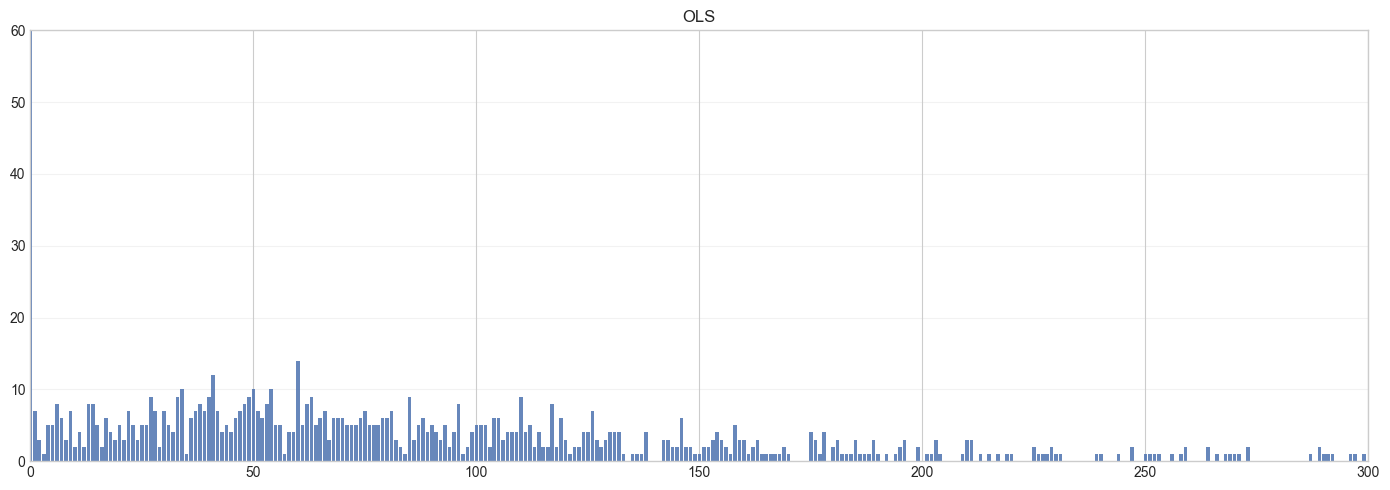

In [180]:
preds["pred_ols_int"] = np.rint(preds["pred_ols"]).clip(lower=0).astype(int)

ols_freq = (
    preds["pred_ols_int"]
    .value_counts()
    .sort_index()
    .rename_axis("pred_ols_int")
    .reset_index(name="freq")
)

show_table(ols_freq, "OLS")

plt.figure(figsize=(14, 5))
plt.bar(ols_freq["pred_ols_int"], ols_freq["freq"], color="#4C72B0", alpha=0.85)
plt.title("OLS")

plt.xlim(0, 300)
plt.ylim(0, 60)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## 3) Метрики по классам жилья (holdout)


In [181]:
by_class_rows = []
pred_cols = {
    nb_off_model_label: ("pred_nb_offset", nb_off_dist_kind, alpha_nb_off),
    "Poisson_offset": ("pred_pois_offset", "poisson", None),
    nb_no_model_label: ("pred_nb_no_offset", nb_no_dist_kind, alpha_nb_no),
    "OLS_baseline": ("pred_ols", "poisson", None),
}

for cls, sub in preds.groupby("class_group"):
    if len(sub) < 20:
        continue
    y_cls = sub["y_true"].to_numpy(dtype=float)
    for m_name, (pred_col, dist_kind, alpha) in pred_cols.items():
        y_hat = sub[pred_col].to_numpy(dtype=float)
        mae = float(np.mean(np.abs(y_cls - y_hat)))
        m_rmse = rmse(y_cls, y_hat)
        pdev = poisson_deviance(y_cls, y_hat)
        calib = float(y_hat.sum() / max(y_cls.sum(), 1e-9))
        chi2, bins_used, _ = distribution_chi2(y_cls, y_hat, dist=dist_kind, alpha=alpha)
        by_class_rows.append(
            {
                "class_group": cls,
                "model": m_name,
                "MAE": mae,
                "RMSE": m_rmse,
                "PoissonDeviance": pdev,
                "Calibration": calib,
                "chi2": chi2,
                "bins_used": bins_used,
                "n_rows": len(sub),
            }
        )

by_class_df = pd.DataFrame(by_class_rows)
class_pivot_mae = by_class_df.pivot(index="class_group", columns="model", values="MAE")
class_pivot_chi2 = by_class_df.pivot(index="class_group", columns="model", values="chi2")

show_table(class_pivot_mae.reset_index(), "MAE по классам")
show_table(class_pivot_chi2.reset_index(), "chi2 распределения по классам")



MAE по классам


model,class_group,NB_no_offset,NB_offset,OLS_baseline,Poisson_offset
0,Бизнес,126.517301,204.317819,56.610820,56.974280
1,Комфорт,105.488301,366.451909,67.063011,77.267318
2,Премиум,22.812993,47.107878,30.704173,24.105870
3,Элитный,9.627141,12.876480,17.029320,9.325314



chi2 распределения по классам


model,class_group,NB_no_offset,NB_offset,OLS_baseline,Poisson_offset
0,Бизнес,170.461670,309.029351,550.351115,259.736500
1,Комфорт,132.385053,325.393838,147.381617,271.429304
2,Премиум,17.388177,26.758058,4.954871,16.459427
3,Элитный,26.458813,12.576967,249.708384,12.219905


## 4) График распределения продаж (весь регион, holdout)

Показываем факт и аппроксимации распределений для `deals_next_q`.


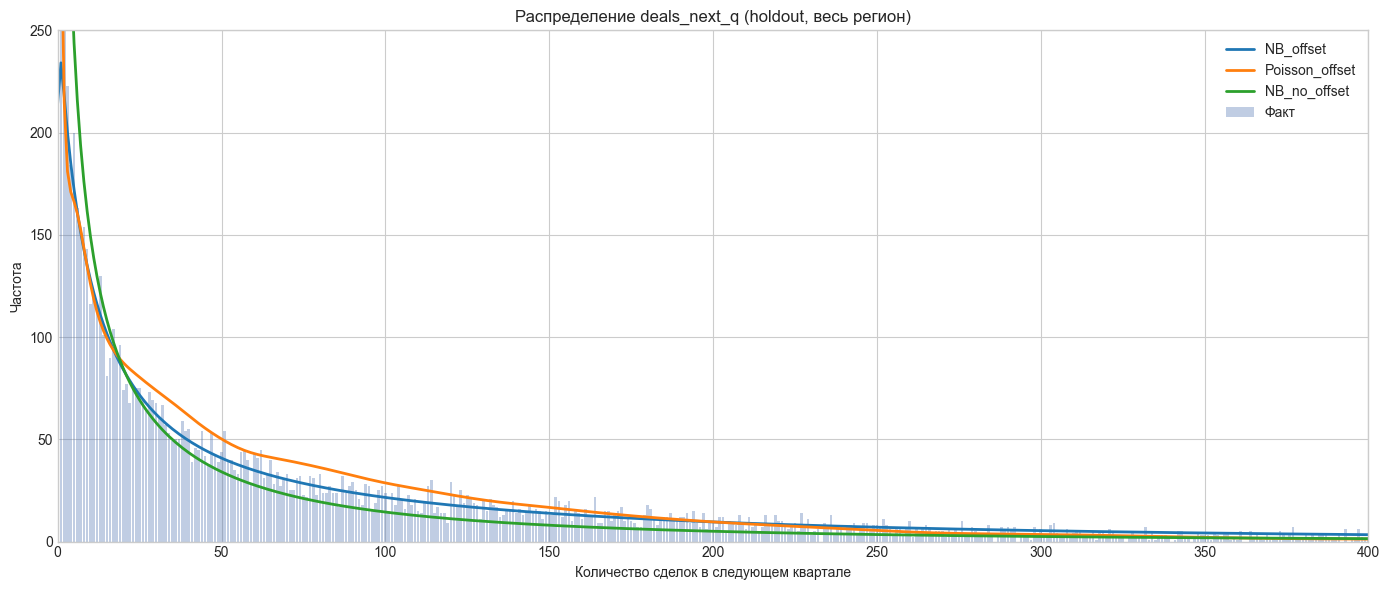


Хвост распределения


,name,freq(>= 580)
0,Факт,95.000000
1,NB_offset,757.908819
2,Poisson_offset,92.554903
3,NB_no_offset,328.015187


In [182]:
def expected_curve(y_true: np.ndarray, mu: np.ndarray, dist: str, alpha: float | None = None):
    y = np.asarray(y_true, dtype=int)
    mu = np.asarray(mu, dtype=float).clip(1e-9, None)
    k_max = int(max(20, min(int(y.max()), int(np.quantile(y, 0.99)) + 5)))
    obs = np.bincount(np.minimum(y, k_max), minlength=k_max + 1).astype(float)

    exp_main = []
    if dist == "poisson":
        for k in range(k_max):
            exp_main.append(float(np.sum(poisson.pmf(k, mu))))
    else:
        a = float(max(alpha if alpha is not None else 0.3, 1e-9))
        r = 1.0 / a
        p = r / (r + mu)
        for k in range(k_max):
            exp_main.append(float(np.sum(nbinom.pmf(k, r, p))))
    exp_main = np.array(exp_main, dtype=float)
    tail = float(len(y) - np.sum(exp_main))
    exp = np.concatenate([exp_main, [max(tail, 1e-9)]])
    return k_max, obs, exp


y_true_all = preds_all["y_true"].to_numpy(dtype=int)
k_max, obs_curve, exp_nb_off = expected_curve(
    y_true_all,
    preds_all["pred_nb_offset"].to_numpy(),
    dist=nb_off_dist_kind_full,
    alpha=alpha_nb_off_full,
)
_, _, exp_pois_off = expected_curve(y_true_all, preds_all["pred_pois_offset"].to_numpy(), dist="poisson")
_, _, exp_nb_no = expected_curve(
    y_true_all,
    preds_all["pred_nb_no_offset"].to_numpy(),
    dist=nb_no_dist_kind_full,
    alpha=alpha_nb_no_full,
)

x = np.arange(k_max)
plt.figure(figsize=(14, 6))
plt.bar(x, obs_curve[:-1], alpha=0.35, color="#4C72B0", label="Факт")
plt.plot(x, exp_nb_off[:-1], lw=2, label=nb_off_model_label_full)
plt.plot(x, exp_pois_off[:-1], lw=2, label="Poisson_offset")
plt.plot(x, exp_nb_no[:-1], lw=2, label=nb_no_model_label_full)

plt.xlim(00, 400)
plt.ylim(0, 250)

plt.title("Распределение deals_next_q (holdout, весь регион)")
plt.xlabel("Количество сделок в следующем квартале")
plt.ylabel("Частота")
plt.legend()
plt.tight_layout()
plt.show()

tail_df = pd.DataFrame(
    {
        "name": ["Факт", nb_off_model_label, "Poisson_offset", nb_no_model_label],
        f"freq(>= {k_max})": [obs_curve[-1], exp_nb_off[-1], exp_pois_off[-1], exp_nb_no[-1]],
    }
)
show_table(tail_df, "Хвост распределения")


## 5) Cumulative Sales Share by Bin

This chart shows the cumulative share of observed sales counts up to each bin `k` (inclusive).



First bins: cumulative share (%)


,sales_bin_k,cumulative_pct
0,0,2.845100
1,1,7.270811
2,2,10.748156
3,3,13.487882
4,4,15.489989
5,5,18.229715
6,6,20.442571
7,7,21.496312
8,8,23.393045
9,9,25.500527


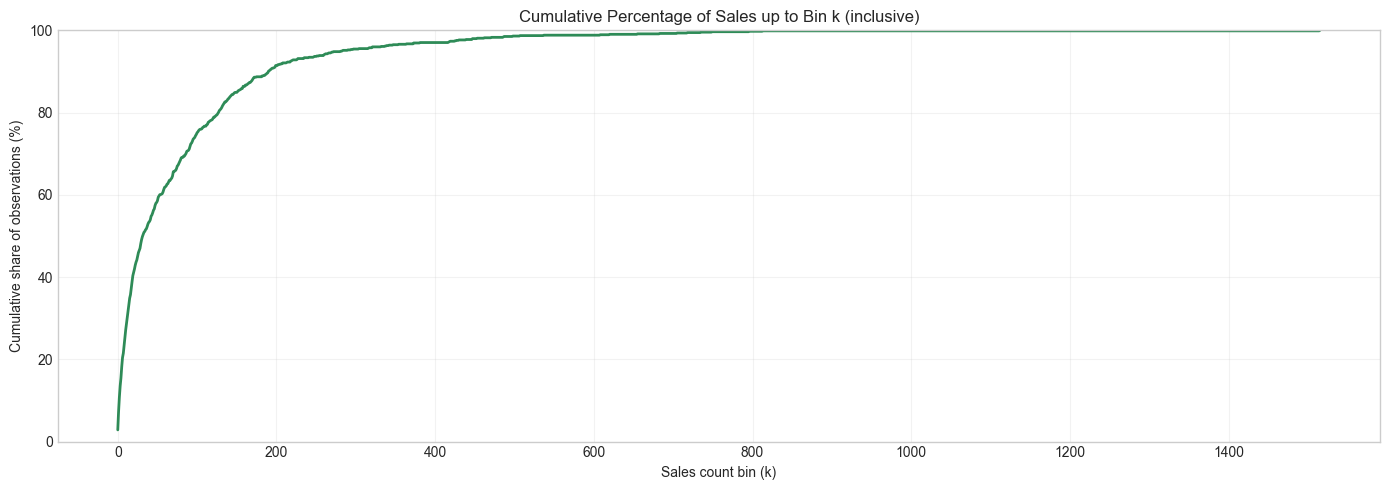

In [183]:
# Build the cumulative distribution of observed holdout sales by bin.
sales_counts = preds["y_true"].astype(int).clip(lower=0).to_numpy()

k_bins = int(sales_counts.max())
bin_axis = np.arange(k_bins + 1)

hist_counts = np.bincount(sales_counts, minlength=k_bins + 1)
cum_pct = 100.0 * np.cumsum(hist_counts) / max(hist_counts.sum(), 1)

cdf_df = pd.DataFrame({
    "sales_bin_k": bin_axis,
    "cumulative_pct": cum_pct,
})

show_table(cdf_df.head(20), "First bins: cumulative share (%)")

plt.figure(figsize=(14, 5))
plt.plot(cdf_df["sales_bin_k"], cdf_df["cumulative_pct"], color="#2E8B57", lw=2)
plt.title("Cumulative Percentage of Sales up to Bin k (inclusive)")
plt.xlabel("Sales count bin (k)")
plt.ylabel("Cumulative share of observations (%)")
plt.ylim(0, 100)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()
